# Parallel lambda-mix sweep across all propagation models

This notebook is the three-shard version of the lambda-mix experiment. Launch
three independent Python/Jupyter processes with environment variable
`LAMBDA_MIX_SHARD_ID` set to `0`, `1`, and `2`.

Each process evaluates two propagation models:

- shard 0: linear consensus and COCA
- shard 1: Hegselmann--Krause and Friedkin--Johnsen
- shard 2: nonlinear influence and repulsion

All shards use the same settings-only trial cache, but write their result tables
to separate directories. Run the accompanying merge notebook after all three
shards finish.

The experiment re-evaluates

\[
M_\lambda(x)
=
(1-\lambda)\widehat A
+
\lambda\left(\widehat A\odot\alpha(x)\right)
\]

for

\[
\lambda_{\mathrm{mix}}
\in
\{0,\ 0.25,\ 0.5,\ 0.7,\ 0.85,\ 1\}
\]

using the online nonlinear identifier and no explicit random exploration.


## Imports and repository setup


In [1]:

from __future__ import annotations

import contextlib
import hashlib
import inspect
import io
import json
import os
import random
import time
import traceback
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError(
        "Could not find the repository root containing opinion_dynamics/. "
        "Place this notebook inside the repository or set REPO_ROOT manually."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in os.sys.path:
    os.sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_eigenvector_centrality,
    compute_laplacian,
)
from opinion_dynamics.baseline import centrality_based_continuous_control
from opinion_dynamics.utils.env_setup import EnvironmentFactory

import opinion_dynamics.experiments.online_single_shot as online_single_shot_module

run_single_shot_online_identification = (
    online_single_shot_module.run_single_shot_online_identification
)


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_35328\2513707949.py:18: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


REPO_ROOT: D:\Work\repos\RL\unknown_graph_networks



## Configuration

The full run evaluates:

\[
6\ \text{dynamics}
\times
6\ \lambda\text{ values}
\times
25\ \text{paired graph/state trials}
=
900\ \text{online trajectories}
\]

Campaign 0 remains passive. Campaigns 1--19 use pure learned control, with no
epsilon-randomized exploration.


In [2]:

# This sharded launcher is intended for CPU execution. Three small models
# competing for one GPU generally perform worse and can exhaust GPU memory.
DEVICE = os.environ.get("LAMBDA_MIX_DEVICE", "cpu").lower()
if DEVICE == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("LAMBDA_MIX_DEVICE=cuda was requested, but CUDA is unavailable.")

NUM_PARALLEL_SHARDS = 3
SHARD_ID = int(os.environ.get("LAMBDA_MIX_SHARD_ID", "0"))
if SHARD_ID not in range(NUM_PARALLEL_SHARDS):
    raise ValueError(
        f"LAMBDA_MIX_SHARD_ID must be 0, 1, or 2; got {SHARD_ID}."
    )

TORCH_THREADS_PER_SHARD = int(
    os.environ.get("LAMBDA_MIX_TORCH_THREADS", "4")
)
torch.set_num_threads(max(1, TORCH_THREADS_PER_SHARD))
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    # PyTorch permits setting this only before inter-op work starts.
    pass

print("Using DEVICE:", DEVICE)
print("Torch threads in this shard:", torch.get_num_threads())

STUDY_DATE = "2026_08_01"
BASE_STUDY_NAME = "lambda_mix_sweep_all_dynamics"
STUDY_NAME = (
    f"{BASE_STUDY_NAME}_shard_{SHARD_ID}_of_{NUM_PARALLEL_SHARDS}"
)

RESULTS_DIR = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
    / f"experiment_{STUDY_DATE}_{STUDY_NAME}"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Current calibrated propagation parameters.
DYNAMICS_SPECS = {
    "laplacian": {
        "label": "Linear consensus",
        "env_kwargs": {},
    },
    "coca": {
        "label": "COCA",
        "env_kwargs": {},
    },
    "hegselmannkrause": {
        "label": "Hegselmann--Krause",
        "env_kwargs": {
            "hk_epsilon": 0.50,
            "hk_include_self": True,
        },
    },
    "friedkinjohnsen": {
        "label": "Friedkin--Johnsen",
        "env_kwargs": {
            "fj_lambda": 0.98,
            "fj_prejudice": None,
        },
    },
    "nonlinearinfluence": {
        "label": "Nonlinear influence",
        "env_kwargs": {
            "nonlinear_beta": 4.0,
        },
    },
    "repulsion": {
        "label": "Repulsion",
        "env_kwargs": {
            "repulsion_epsilon": 0.30,
            "repulsion_strength": 0.10,
        },
    },
}

SHARD_ASSIGNMENTS = {
    0: ["laplacian", "coca"],
    1: ["hegselmannkrause", "friedkinjohnsen"],
    2: ["nonlinearinfluence", "repulsion"],
}
ENABLED_DYNAMICS = SHARD_ASSIGNMENTS[SHARD_ID]

DYNAMICS_LABELS = {
    name: spec["label"]
    for name, spec in DYNAMICS_SPECS.items()
}
DYNAMICS_SEED_INDEX = {
    name: index
    for index, name in enumerate(DYNAMICS_SPECS)
}

LAMBDA_MIX_VALUES = [0.0, 0.25, 0.50, 0.70, 0.85, 1.0]
REFERENCE_LAMBDA = 0.70

QUICK_RUN = False
DEBUG_SHORT_FITS = False
FAIL_FAST = True
RUN_DYNAMICS_PREFLIGHT = True
SAVE_PROGRESS_EVERY_TRIAL = True

if QUICK_RUN:
    TOPOLOGY_SEEDS = [3, 4]
    INITIAL_PERMUTATION_SEEDS = [0, 1]
else:
    TOPOLOGY_SEEDS = [3, 4, 5, 6, 7]
    INITIAL_PERMUTATION_SEEDS = [0, 1, 2, 4, 5]

# Paper-style environment and campaign settings.
N_AGENTS = 15
OMEGA = 1.0
U_BAR = 0.2

NUM_CAMPAIGNS_TOTAL = 20
T_CAMPAIGN = 0.5
T_S = 0.1
TOTAL_CONTROLLED_BUDGET = 6.0
B_CAMPAIGN = TOTAL_CONTROLLED_BUDGET / (NUM_CAMPAIGNS_TOTAL - 1)

# No explicit exploration: passive campaign 0, pure learned control afterwards.
EPSILON_SCHEDULE = [0.0] * NUM_CAMPAIGNS_TOTAL
EXPLORATION_CAMPAIGNS = 0

# Nonlinear identifier settings.
LR = 1e-3
L2_LAMBDA = 0.0
FIT_MAX_STEPS = 300 if DEBUG_SHORT_FITS else 1_000
FIT_MAE_STOP = 5e-4
FIT_BATCH_SIZE = 256
FIT_CHECK_EVERY = 100 if DEBUG_SHORT_FITS else 200
IDENTIFIER_KWARGS = {"hidden_dim": 16}

INITIAL_STATE_SEED_BASE = 920_000
TRAIN_SEED_BASE = 421_000
TRIAL_RNG_SEED_BASE = 731_000

# Settings-only cache. Increase CACHE_VERSION only when a code change makes
# existing cached trials scientifically incompatible.
USE_TRIAL_CACHE = True
FORCE_RERUN_CACHED_TRIALS = False
CACHE_SCHEMA_VERSION = 1
CACHE_VERSION = "v1"

# All shards share one cache namespace. Trial hashes remain unique because
# dynamics, seeds, lambda_mix, and all scientific settings are part of the key.
CACHE_DIR = (
    RESULTS_DIR.parent
    / "_trial_cache"
    / BASE_STUDY_NAME
)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Shard: {SHARD_ID + 1}/{NUM_PARALLEL_SHARDS}")
print("Enabled dynamics:", ENABLED_DYNAMICS)
print("Results directory:", RESULTS_DIR)
print("Shared trial cache:", CACHE_DIR)
print(
    "Expected online trajectories:",
    len(ENABLED_DYNAMICS)
    * len(LAMBDA_MIX_VALUES)
    * len(TOPOLOGY_SEEDS)
    * len(INITIAL_PERMUTATION_SEEDS),
)
print("Trials per dynamics/lambda:", len(TOPOLOGY_SEEDS) * len(INITIAL_PERMUTATION_SEEDS))
print("Budget per controlled campaign:", B_CAMPAIGN)


Using DEVICE: cpu
Torch threads in this shard: 3
Shard: 2/3
Enabled dynamics: ['hegselmannkrause', 'friedkinjohnsen']
Results directory: D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_01_lambda_mix_sweep_all_dynamics_shard_1_of_3
Shared trial cache: D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\_trial_cache\lambda_mix_sweep_all_dynamics
Expected online trajectories: 300
Trials per dynamics/lambda: 25
Budget per controlled campaign: 0.3157894736842105



## Environment and reproducibility helpers

One topology is generated for each topology seed and reused across all
propagation models and lambda values. For a fixed dynamics/topology/initial
combination, every lambda value also receives the same identifier
initialization seed.


In [3]:

def set_global_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def sanitize_centrality(
    centrality: np.ndarray,
    eps: float = 1e-12,
) -> np.ndarray:
    v = np.asarray(centrality, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)

    if float(v.sum()) < 0:
        v = -v

    v = np.maximum(v, 0.0)
    total = float(v.sum())

    if total <= eps:
        v = np.abs(v)
        total = float(v.sum())

    if total <= eps:
        return np.full(v.shape, 1.0 / len(v), dtype=float)

    return v / total


def centrality_from_matrix(matrix: np.ndarray) -> np.ndarray:
    return sanitize_centrality(
        compute_eigenvector_centrality(
            compute_laplacian(
                np.asarray(matrix, dtype=float)
            )
        )
    )


def make_initial_opinions(
    n: int,
    permutation_seed: int,
) -> np.ndarray:
    rng = np.random.default_rng(
        INITIAL_STATE_SEED_BASE + int(permutation_seed)
    )
    return rng.permutation(
        np.linspace(0.0, 1.0, int(n), dtype=float)
    )


def set_initial_state(env: Any, x0: np.ndarray) -> None:
    x0 = np.asarray(x0, dtype=float).reshape(-1)

    if hasattr(env, "initial_opinions"):
        try:
            env.initial_opinions = x0.copy()
        except Exception:
            pass

    env.opinions = x0.copy()

    if hasattr(env, "state"):
        try:
            env.state = x0.copy()
        except Exception:
            pass

    # When prejudice was not explicitly supplied, FJ uses the trial initial state.
    if str(getattr(env, "dynamics_model", "")).lower() in {
        "friedkinjohnsen",
        "friedkin_johnsen",
        "fj",
    }:
        env.fj_prejudice = x0.copy()


def copy_env_value(value: Any) -> Any:
    if isinstance(value, np.ndarray):
        return np.array(value, copy=True)
    if isinstance(value, list):
        return list(value)
    if isinstance(value, tuple):
        return tuple(value)
    return value


def filter_constructor_kwargs(
    env_class: type,
    kwargs: Dict[str, Any],
    *,
    required_keys: Iterable[str] = (),
) -> Dict[str, Any]:
    signature = inspect.signature(env_class.__init__)
    parameters = signature.parameters

    if any(
        parameter.kind == inspect.Parameter.VAR_KEYWORD
        for parameter in parameters.values()
    ):
        return dict(kwargs)

    accepted = {
        name
        for name, parameter in parameters.items()
        if name != "self"
        and parameter.kind
        in {
            inspect.Parameter.POSITIONAL_OR_KEYWORD,
            inspect.Parameter.KEYWORD_ONLY,
        }
    }

    missing_required = sorted(set(required_keys) - accepted)
    if missing_required:
        raise RuntimeError(
            "The installed NetworkGraph constructor does not support "
            f"{missing_required}. Update the local rl-envs-forge checkout."
        )

    return {
        key: value
        for key, value in kwargs.items()
        if key in accepted
    }


def make_topology_template(topology_seed: int) -> Any:
    factory = EnvironmentFactory()
    env = factory.get_randomized_env(
        seed=int(topology_seed),
        dynamics_model="laplacian",
    )
    if int(env.num_agents) != N_AGENTS:
        raise RuntimeError(
            f"Expected N_AGENTS={N_AGENTS}, got {env.num_agents}. "
            "Update N_AGENTS or the environment factory settings."
        )
    return env


def env_kwargs_from_template(
    env_template: Any,
    *,
    dynamics_model: Optional[str] = None,
    dynamics_overrides: Optional[Dict[str, Any]] = None,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    terminate_when_converged: bool = False,
) -> Dict[str, Any]:
    n = int(env_template.num_agents)
    model_name = str(
        dynamics_model
        if dynamics_model is not None
        else getattr(env_template, "dynamics_model", "laplacian")
    )

    initial_opinions = getattr(
        env_template,
        "initial_opinions",
        None,
    )

    kwargs: Dict[str, Any] = {
        "connectivity_matrix": np.array(
            env_template.connectivity_matrix,
            copy=True,
        ),
        "num_agents": n,
        "max_u": np.full(n, U_BAR, dtype=float),
        "desired_opinion": float(OMEGA),
        "t_campaign": float(t_campaign),
        "t_s": float(t_s),
        "dynamics_model": model_name,
        "initial_opinions": (
            None
            if initial_opinions is None
            else np.array(initial_opinions, copy=True)
        ),
        "initial_opinion_range": tuple(
            getattr(
                env_template,
                "initial_opinion_range",
                (0.0, 1.0),
            )
        ),
        "control_resistance": np.array(
            getattr(
                env_template,
                "control_resistance",
                np.zeros(n),
            ),
            copy=True,
        ),
        "max_steps": int(
            getattr(env_template, "max_steps", 10_000)
        ),
        "opinion_end_tolerance": float(
            getattr(
                env_template,
                "opinion_end_tolerance",
                0.01,
            )
        ),
        "control_beta": float(
            getattr(env_template, "control_beta", 0.4)
        ),
        "normalize_reward": bool(
            getattr(
                env_template,
                "normalize_reward",
                False,
            )
        ),
        "terminal_reward": float(
            getattr(env_template, "terminal_reward", 0.0)
        ),
        "terminate_when_converged": bool(
            terminate_when_converged
        ),
        "budget": copy_env_value(
            getattr(env_template, "budget", None)
        ),
        "use_delta_shaping": bool(
            getattr(
                env_template,
                "use_delta_shaping",
                False,
            )
        ),
        "delta_lambda": float(
            getattr(env_template, "delta_lambda", 0.0)
        ),
        "seed": (
            int(getattr(env_template, "seed", 0))
            if getattr(env_template, "seed", None) is not None
            else None
        ),
    }

    for attribute in [
        "fj_lambda",
        "fj_prejudice",
        "hk_epsilon",
        "hk_include_self",
        "nonlinear_beta",
        "repulsion_epsilon",
        "repulsion_strength",
    ]:
        if hasattr(env_template, attribute):
            kwargs[attribute] = copy_env_value(
                getattr(env_template, attribute)
            )

    if dynamics_overrides:
        for key, value in dynamics_overrides.items():
            kwargs[key] = copy_env_value(value)

    return filter_constructor_kwargs(
        env_template.__class__,
        kwargs,
        required_keys=set(
            (dynamics_overrides or {}).keys()
        ),
    )


def clone_env_from_template(
    env_template: Any,
    *,
    dynamics_model: Optional[str] = None,
    dynamics_overrides: Optional[Dict[str, Any]] = None,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    terminate_when_converged: bool = False,
) -> Any:
    kwargs = env_kwargs_from_template(
        env_template,
        dynamics_model=dynamics_model,
        dynamics_overrides=dynamics_overrides,
        t_campaign=t_campaign,
        t_s=t_s,
        terminate_when_converged=terminate_when_converged,
    )
    return env_template.__class__(**kwargs)


def make_env_for_dynamics(
    topology_template: Any,
    dynamics: str,
) -> Any:
    if dynamics not in DYNAMICS_SPECS:
        raise KeyError(f"Unknown dynamics: {dynamics}")

    return clone_env_from_template(
        topology_template,
        dynamics_model=dynamics,
        dynamics_overrides=(
            DYNAMICS_SPECS[dynamics]["env_kwargs"]
        ),
        terminate_when_converged=False,
    )


# Patch the cloning hooks used by the current online nonlinear runner so all
# dynamics-specific settings survive environment reconstruction.
def online_env_kwargs_from_env(
    env: Any,
    *,
    t_campaign: Optional[float] = None,
    t_s: Optional[float] = None,
) -> Dict[str, Any]:
    return env_kwargs_from_template(
        env,
        dynamics_model=str(
            getattr(env, "dynamics_model", "laplacian")
        ),
        dynamics_overrides=None,
        t_campaign=float(
            env.t_campaign
            if t_campaign is None
            else t_campaign
        ),
        t_s=float(
            env.t_s
            if t_s is None
            else t_s
        ),
        terminate_when_converged=bool(
            getattr(
                env,
                "terminate_when_converged",
                False,
            )
        ),
    )


def online_make_env_from_template(
    env_template: Any,
    *,
    t_campaign: Optional[float] = None,
    t_s: Optional[float] = None,
) -> Any:
    kwargs = online_env_kwargs_from_env(
        env_template,
        t_campaign=t_campaign,
        t_s=t_s,
    )
    return env_template.__class__(**kwargs)


online_single_shot_module.env_kwargs_from_env = (
    online_env_kwargs_from_env
)
online_single_shot_module.make_env_from_template = (
    online_make_env_from_template
)
run_single_shot_online_identification = (
    online_single_shot_module.run_single_shot_online_identification
)



## Baseline, metric, and trajectory helpers


In [4]:

POLICY_NONLINEAR = "online_nonlinear_lambda_mix"
POLICY_TRUE_GRAPH = "true_graph_centrality"
POLICY_UNIFORM = "uniform"
POLICY_NOCONTROL = "no_control"

POLICY_LABELS = {
    POLICY_NONLINEAR: "online nonlinear identifier",
    POLICY_TRUE_GRAPH: "true-graph centrality",
    POLICY_UNIFORM: "uniform",
    POLICY_NOCONTROL: "no control",
}


def as_vector_max_u(max_u: Any, n: int) -> np.ndarray:
    values = np.asarray(max_u, dtype=float)

    if values.ndim == 0:
        return np.full(n, float(values), dtype=float)

    values = values.reshape(-1).astype(float)
    if values.shape != (n,):
        raise ValueError(
            f"max_u must be scalar or shape ({n},), got {values.shape}"
        )

    return values


def uniform_budget_action(
    max_u: np.ndarray,
    budget: float,
) -> np.ndarray:
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    action = np.zeros_like(max_u)
    remaining = min(
        float(budget),
        float(max_u.sum()),
    )
    active = np.ones(max_u.size, dtype=bool)

    while remaining > 1e-12 and active.any():
        indices = np.flatnonzero(active)
        share = remaining / len(indices)
        progressed = False

        for index in indices:
            available = float(
                max_u[index] - action[index]
            )
            allocation = min(share, available)

            if allocation > 0:
                action[index] += allocation
                remaining -= allocation
                progressed = True

            if action[index] >= max_u[index] - 1e-12:
                active[index] = False

        if not progressed:
            break

    return action


def rollout_fixed_policy(
    env_template: Any,
    x0: np.ndarray,
    *,
    policy: str,
    v_true: Optional[np.ndarray] = None,
) -> Dict[str, Any]:
    env = clone_env_from_template(
        env_template,
        terminate_when_converged=False,
    )
    env.reset()
    set_initial_state(env, x0)

    states = [np.asarray(x0, dtype=float).copy()]
    actions = []
    rewards = []
    times = [0.0]

    max_u = as_vector_max_u(
        env.max_u,
        int(env.num_agents),
    )

    for campaign in range(NUM_CAMPAIGNS_TOTAL):
        if campaign == 0 or policy == POLICY_NOCONTROL:
            action = np.zeros(
                env.num_agents,
                dtype=float,
            )
        elif policy == POLICY_UNIFORM:
            action = uniform_budget_action(
                max_u,
                B_CAMPAIGN,
            )
        elif policy == POLICY_TRUE_GRAPH:
            if v_true is None:
                raise ValueError(
                    "v_true is required for true-graph centrality"
                )
            action, _ = centrality_based_continuous_control(
                env,
                B_CAMPAIGN,
                v=v_true,
            )
            action = np.asarray(action, dtype=float)
        else:
            raise ValueError(f"Unknown baseline policy: {policy}")

        x_next, reward, done, truncated, info = env.step(
            action
        )

        states.append(
            np.asarray(x_next, dtype=float).copy()
        )
        actions.append(action.copy())
        rewards.append(float(reward))
        times.append(
            times[-1] + float(env.t_campaign)
        )

        if done or truncated:
            break

    return {
        "policy": policy,
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(times, dtype=float),
    }


def normalize_online_output(
    output: Dict[str, Any],
) -> Dict[str, Any]:
    output = dict(output)
    output["policy"] = POLICY_NONLINEAR

    if (
        "boundary_times" not in output
        or output["boundary_times"] is None
    ):
        output["boundary_times"] = (
            np.arange(
                len(output["states"]),
                dtype=float,
            )
            * T_CAMPAIGN
        )

    return output


def final_mean(rollout: Dict[str, Any]) -> float:
    return float(
        np.asarray(
            rollout["states"],
            dtype=float,
        )[-1].mean()
    )


def trajectory_rows(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    lambda_mix: float,
    policy: str,
    rollout: Dict[str, Any],
) -> List[Dict[str, Any]]:
    states = np.asarray(
        rollout["states"],
        dtype=float,
    )
    times = np.asarray(
        rollout["boundary_times"],
        dtype=float,
    )

    rows = []
    for boundary_index, (time_value, state) in enumerate(
        zip(times, states)
    ):
        rows.append(
            {
                "dynamics": dynamics,
                "dynamics_label": DYNAMICS_LABELS[dynamics],
                "topology_seed": int(topology_seed),
                "initial_seed": int(initial_seed),
                "lambda_mix": float(lambda_mix),
                "policy": policy,
                "policy_label": POLICY_LABELS[policy],
                "boundary_index": int(boundary_index),
                "time": float(time_value),
                "mean_opinion": float(np.mean(state)),
                "std_opinion": float(np.std(state)),
                "min_opinion": float(np.min(state)),
                "max_opinion": float(np.max(state)),
            }
        )

    return rows


def summarize_learned_trial(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    lambda_mix: float,
    learned: Dict[str, Any],
    true_graph: Dict[str, Any],
    uniform: Dict[str, Any],
    no_control: Dict[str, Any],
    A_true: np.ndarray,
    v_true: np.ndarray,
) -> Dict[str, Any]:
    learned_end = final_mean(learned)
    true_graph_end = final_mean(true_graph)
    uniform_end = final_mean(uniform)
    no_control_end = final_mean(no_control)

    A_hats = learned.get("A_hats", [])
    v_hats = (
        learned.get("v_hats_lambda", [])
        or learned.get("v_hats_static", [])
    )
    fit_infos = learned.get("fit_infos", [])

    row: Dict[str, Any] = {
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS[dynamics],
        "topology_seed": int(topology_seed),
        "initial_seed": int(initial_seed),
        "trial_id": (
            f"{dynamics}|topo={topology_seed}|init={initial_seed}"
        ),
        "lambda_mix": float(lambda_mix),
        "mean_end": learned_end,
        "mean_true_graph_end": true_graph_end,
        "mean_uniform_end": uniform_end,
        "mean_nocontrol_end": no_control_end,
        "model_minus_true_graph_mean_end": (
            learned_end - true_graph_end
        ),
        "model_minus_uniform_mean_end": (
            learned_end - uniform_end
        ),
        "model_minus_nocontrol_mean_end": (
            learned_end - no_control_end
        ),
    }

    if A_hats:
        A_final = np.asarray(
            A_hats[-1],
            dtype=float,
        )
        row["A_MAE_final"] = float(
            np.mean(np.abs(A_final - A_true))
        )
        row["A_Fro_final"] = float(
            np.linalg.norm(
                A_final - A_true,
                ord="fro",
            )
        )

    if v_hats:
        v_final = np.asarray(
            v_hats[-1],
            dtype=float,
        )
        row["final_v_L1"] = float(
            np.sum(np.abs(v_final - v_true))
        )

    if fit_infos:
        last_fit = fit_infos[-1]
        row.update(
            {
                "final_train_mae": float(
                    last_fit["train_mae"]
                ),
                "final_identity_mae": float(
                    last_fit["identity_mae"]
                ),
                "final_model_over_identity": float(
                    last_fit["model_over_identity"]
                ),
                "final_n_pairs": int(
                    last_fit["n_pairs"]
                ),
                "total_fit_time_sec": float(
                    sum(
                        item.get(
                            "fit_time_sec",
                            item.get(
                                "fit_elapsed_s",
                                0.0,
                            ),
                        )
                        for item in fit_infos
                    )
                ),
            }
        )

    return row


def fit_rows_from_output(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    lambda_mix: float,
    learned: Dict[str, Any],
) -> List[Dict[str, Any]]:
    rows = []

    for item in learned.get("fit_infos", []):
        row = {
            "dynamics": dynamics,
            "dynamics_label": DYNAMICS_LABELS[dynamics],
            "topology_seed": int(topology_seed),
            "initial_seed": int(initial_seed),
            "lambda_mix": float(lambda_mix),
        }
        row.update(item)
        rows.append(row)

    return rows



## Windows-safe settings-only cache

Each successful lambda trial stores:

- one summary JSON
- one trajectory CSV
- one fit-history CSV
- one manifest written last

A partial directory without a successful manifest is ignored and rerun.


In [5]:

def json_safe(value: Any) -> Any:
    if isinstance(value, dict):
        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    return value


def trial_hash(settings: Dict[str, Any]) -> str:
    payload = json.dumps(
        json_safe(settings),
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()[:24]


def cache_trial_dir(hash_value: str) -> Path:
    return CACHE_DIR / hash_value


def atomic_write_text(
    path: Path,
    text: str,
) -> None:
    temporary = path.with_suffix(
        path.suffix + ".tmp"
    )
    temporary.write_text(
        text,
        encoding="utf-8",
    )
    os.replace(temporary, path)


def atomic_write_csv(
    path: Path,
    dataframe: pd.DataFrame,
) -> None:
    temporary = path.with_suffix(
        path.suffix + ".tmp"
    )
    dataframe.to_csv(
        temporary,
        index=False,
    )
    os.replace(temporary, path)


def cache_is_complete(
    directory: Path,
) -> bool:
    manifest_path = directory / "manifest.json"

    if not manifest_path.exists():
        return False

    try:
        manifest = json.loads(
            manifest_path.read_text(
                encoding="utf-8"
            )
        )
    except Exception:
        return False

    required = [
        directory / "summary.json",
        directory / "trajectory.csv",
        directory / "fit.csv",
    ]

    return (
        manifest.get("status") == "success"
        and all(path.exists() for path in required)
    )


def save_trial_cache(
    *,
    hash_value: str,
    settings: Dict[str, Any],
    summary_row: Dict[str, Any],
    trajectory: pd.DataFrame,
    fit: pd.DataFrame,
) -> None:
    directory = cache_trial_dir(hash_value)
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    atomic_write_text(
        directory / "summary.json",
        json.dumps(
            json_safe(summary_row),
            indent=2,
            sort_keys=True,
        ),
    )
    atomic_write_csv(
        directory / "trajectory.csv",
        trajectory,
    )
    atomic_write_csv(
        directory / "fit.csv",
        fit,
    )

    manifest = {
        "status": "success",
        "schema_version": CACHE_SCHEMA_VERSION,
        "cache_version": CACHE_VERSION,
        "trial_hash": hash_value,
        "created_utc": datetime.now(
            timezone.utc
        ).isoformat(),
        "settings": json_safe(settings),
    }

    # Manifest is written last, so interrupted writes cannot become cache hits.
    atomic_write_text(
        directory / "manifest.json",
        json.dumps(
            manifest,
            indent=2,
            sort_keys=True,
        ),
    )


def load_trial_cache(
    hash_value: str,
) -> Tuple[
    Dict[str, Any],
    pd.DataFrame,
    pd.DataFrame,
]:
    directory = cache_trial_dir(hash_value)

    if not cache_is_complete(directory):
        raise FileNotFoundError(
            f"Incomplete cache entry: {directory}"
        )

    summary = json.loads(
        (directory / "summary.json").read_text(
            encoding="utf-8"
        )
    )
    trajectory = pd.read_csv(
        directory / "trajectory.csv"
    )
    fit = pd.read_csv(
        directory / "fit.csv"
    )

    return summary, trajectory, fit



## Propagation-model preflight


In [6]:

def preflight_enabled_dynamics() -> pd.DataFrame:
    topology = make_topology_template(
        TOPOLOGY_SEEDS[0]
    )
    x0 = make_initial_opinions(
        topology.num_agents,
        INITIAL_PERMUTATION_SEEDS[0],
    )

    rows = []

    for dynamics in ENABLED_DYNAMICS:
        env = make_env_for_dynamics(
            topology,
            dynamics,
        )
        env.reset()
        set_initial_state(env, x0)

        action = np.zeros(
            env.num_agents,
            dtype=float,
        )
        x_next, reward, done, truncated, info = env.step(
            action
        )

        intermediate = info.get(
            "intermediate_states",
            None,
        )
        if intermediate is None:
            raise RuntimeError(
                f"{dynamics} did not return intermediate_states"
            )

        x_next = np.asarray(
            x_next,
            dtype=float,
        )
        if not np.isfinite(x_next).all():
            raise RuntimeError(
                f"{dynamics} produced nonfinite opinions"
            )

        rows.append(
            {
                "dynamics": dynamics,
                "label": DYNAMICS_LABELS[dynamics],
                "num_agents": int(env.num_agents),
                "intermediate_states": int(
                    np.asarray(intermediate).shape[0]
                ),
                "next_mean": float(x_next.mean()),
                "next_min": float(x_next.min()),
                "next_max": float(x_next.max()),
            }
        )

    return pd.DataFrame(rows)


if RUN_DYNAMICS_PREFLIGHT:
    preflight_df = preflight_enabled_dynamics()
    display(preflight_df)


,dynamics,label,num_agents,intermediate_states,next_mean,next_min,next_max
0,hegselmannkrause,Hegselmann--Krause,15,6,0.522436,0.381618,0.640922
1,friedkinjohnsen,Friedkin--Johnsen,15,6,0.520070,0.456402,0.585161



## Run the lambda-mix sweep

Uniform, no-control, and true-graph baselines are computed once for each
dynamics/topology/initial-state combination and reused for all lambda values.

For fair paired comparison, the nonlinear identifier receives the same initial
random seed for every lambda value within a fixed trial.


In [7]:

summary_rows: List[Dict[str, Any]] = []
trajectory_rows_all: List[Dict[str, Any]] = []
fit_rows_all: List[Dict[str, Any]] = []
failure_rows: List[Dict[str, Any]] = []
run_index_rows: List[Dict[str, Any]] = []

cache_hits = 0
new_trials = 0

expected_trials = (
    len(ENABLED_DYNAMICS)
    * len(LAMBDA_MIX_VALUES)
    * len(TOPOLOGY_SEEDS)
    * len(INITIAL_PERMUTATION_SEEDS)
)
completed = 0
start_time = time.perf_counter()

for topology_seed in TOPOLOGY_SEEDS:
    topology_template = make_topology_template(
        topology_seed
    )

    for dynamics in ENABLED_DYNAMICS:
        env_template = make_env_for_dynamics(
            topology_template,
            dynamics,
        )

        A_true = np.asarray(
            env_template.connectivity_matrix,
            dtype=float,
        )
        v_true = centrality_from_matrix(A_true)

        for initial_seed in INITIAL_PERMUTATION_SEEDS:
            x0 = make_initial_opinions(
                env_template.num_agents,
                initial_seed,
            )

            # Baselines are lambda-independent.
            true_graph = rollout_fixed_policy(
                env_template,
                x0,
                policy=POLICY_TRUE_GRAPH,
                v_true=v_true,
            )
            uniform = rollout_fixed_policy(
                env_template,
                x0,
                policy=POLICY_UNIFORM,
            )
            no_control = rollout_fixed_policy(
                env_template,
                x0,
                policy=POLICY_NOCONTROL,
            )

            dynamics_index = DYNAMICS_SEED_INDEX[dynamics]
            paired_train_seed = (
                TRAIN_SEED_BASE
                + 10_000_000 * dynamics_index
                + 100_000 * int(topology_seed)
                + 1_000 * int(initial_seed)
            )
            paired_rng_seed = (
                TRIAL_RNG_SEED_BASE
                + 10_000_000 * dynamics_index
                + 100_000 * int(topology_seed)
                + 1_000 * int(initial_seed)
            )

            for lambda_mix in LAMBDA_MIX_VALUES:
                completed += 1

                settings = {
                    "cache_schema_version": CACHE_SCHEMA_VERSION,
                    "cache_version": CACHE_VERSION,
                    "study_name": BASE_STUDY_NAME,
                    "dynamics": dynamics,
                    "dynamics_env_kwargs": (
                        DYNAMICS_SPECS[dynamics]["env_kwargs"]
                    ),
                    "topology_seed": int(topology_seed),
                    "initial_seed": int(initial_seed),
                    "lambda_mix": float(lambda_mix),
                    "n_agents": N_AGENTS,
                    "omega": OMEGA,
                    "u_bar": U_BAR,
                    "num_campaigns_total": NUM_CAMPAIGNS_TOTAL,
                    "t_campaign": T_CAMPAIGN,
                    "t_s": T_S,
                    "total_controlled_budget": TOTAL_CONTROLLED_BUDGET,
                    "B_campaign": B_CAMPAIGN,
                    "epsilon_schedule": EPSILON_SCHEDULE,
                    "exploration_campaigns": EXPLORATION_CAMPAIGNS,
                    "lr": LR,
                    "l2_lambda": L2_LAMBDA,
                    "fit_max_steps": FIT_MAX_STEPS,
                    "fit_mae_stop": FIT_MAE_STOP,
                    "fit_batch_size": FIT_BATCH_SIZE,
                    "fit_check_every": FIT_CHECK_EVERY,
                    "identifier_kwargs": IDENTIFIER_KWARGS,
                    "train_seed": int(paired_train_seed),
                    "rng_seed": int(paired_rng_seed),
                }
                hash_value = trial_hash(settings)

                try:
                    if (
                        USE_TRIAL_CACHE
                        and not FORCE_RERUN_CACHED_TRIALS
                        and cache_is_complete(
                            cache_trial_dir(hash_value)
                        )
                    ):
                        summary_row, trajectory_cached, fit_cached = (
                            load_trial_cache(hash_value)
                        )
                        summary_rows.append(summary_row)
                        trajectory_rows_all.extend(
                            trajectory_cached.to_dict(
                                orient="records"
                            )
                        )
                        fit_rows_all.extend(
                            fit_cached.to_dict(
                                orient="records"
                            )
                        )
                        cache_hits += 1
                        status = "cache_hit"

                    else:
                        set_global_seed(paired_train_seed)

                        learned = (
                            run_single_shot_online_identification(
                                env_template,
                                x0=x0,
                                random_initial_opinions=False,
                                num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                                t_campaign=T_CAMPAIGN,
                                t_s=T_S,
                                B_campaign=B_CAMPAIGN,
                                lambda_mix=float(lambda_mix),
                                exploration_campaigns=(
                                    EXPLORATION_CAMPAIGNS
                                ),
                                epsilon_schedule=EPSILON_SCHEDULE,
                                lr=LR,
                                l2_lambda=L2_LAMBDA,
                                fit_max_steps=FIT_MAX_STEPS,
                                fit_mae_stop=FIT_MAE_STOP,
                                fit_batch_size=FIT_BATCH_SIZE,
                                fit_check_every=FIT_CHECK_EVERY,
                                identifier_kwargs=IDENTIFIER_KWARGS,
                                device=DEVICE,
                                rng_seed=paired_rng_seed,
                                suppress_fit_logs=True,
                            )
                        )
                        learned = normalize_online_output(
                            learned
                        )

                        summary_row = summarize_learned_trial(
                            dynamics=dynamics,
                            topology_seed=topology_seed,
                            initial_seed=initial_seed,
                            lambda_mix=lambda_mix,
                            learned=learned,
                            true_graph=true_graph,
                            uniform=uniform,
                            no_control=no_control,
                            A_true=A_true,
                            v_true=v_true,
                        )
                        summary_row.update(
                            {
                                "trial_hash": hash_value,
                                "cache_version": CACHE_VERSION,
                            }
                        )

                        trajectory_records = []
                        for policy, rollout in [
                            (POLICY_NONLINEAR, learned),
                            (POLICY_TRUE_GRAPH, true_graph),
                            (POLICY_UNIFORM, uniform),
                            (POLICY_NOCONTROL, no_control),
                        ]:
                            trajectory_records.extend(
                                trajectory_rows(
                                    dynamics=dynamics,
                                    topology_seed=topology_seed,
                                    initial_seed=initial_seed,
                                    lambda_mix=lambda_mix,
                                    policy=policy,
                                    rollout=rollout,
                                )
                            )

                        fit_records = fit_rows_from_output(
                            dynamics=dynamics,
                            topology_seed=topology_seed,
                            initial_seed=initial_seed,
                            lambda_mix=lambda_mix,
                            learned=learned,
                        )

                        summary_rows.append(summary_row)
                        trajectory_rows_all.extend(
                            trajectory_records
                        )
                        fit_rows_all.extend(fit_records)

                        if USE_TRIAL_CACHE:
                            save_trial_cache(
                                hash_value=hash_value,
                                settings=settings,
                                summary_row=summary_row,
                                trajectory=pd.DataFrame(
                                    trajectory_records
                                ),
                                fit=pd.DataFrame(fit_records),
                            )

                        new_trials += 1
                        status = "executed"

                    run_index_rows.append(
                        {
                            "trial_hash": hash_value,
                            "dynamics": dynamics,
                            "topology_seed": int(topology_seed),
                            "initial_seed": int(initial_seed),
                            "lambda_mix": float(lambda_mix),
                            "status": status,
                        }
                    )

                    elapsed_now = time.perf_counter() - start_time
                    mean_seconds = elapsed_now / max(completed, 1)
                    remaining_seconds = mean_seconds * (
                        expected_trials - completed
                    )
                    eta_hours = remaining_seconds / 3600.0

                    print(
                        f"[{completed:>3}/{expected_trials}] "
                        f"{dynamics:>20} | "
                        f"topo={topology_seed} | "
                        f"init={initial_seed} | "
                        f"lambda={lambda_mix:.2f} | "
                        f"{status} | ETA {eta_hours:.2f} h"
                    )

                    if SAVE_PROGRESS_EVERY_TRIAL:
                        pd.DataFrame(summary_rows).to_csv(
                            RESULTS_DIR / "summary_partial.csv",
                            index=False,
                        )
                        pd.DataFrame(run_index_rows).to_csv(
                            RESULTS_DIR / "run_index_partial.csv",
                            index=False,
                        )
                        pd.DataFrame(failure_rows).to_csv(
                            RESULTS_DIR / "failures_partial.csv",
                            index=False,
                        )

                except Exception as exc:
                    failure = {
                        "trial_hash": hash_value,
                        "dynamics": dynamics,
                        "topology_seed": int(topology_seed),
                        "initial_seed": int(initial_seed),
                        "lambda_mix": float(lambda_mix),
                        "error": repr(exc),
                        "traceback": traceback.format_exc(),
                    }
                    failure_rows.append(failure)
                    run_index_rows.append(
                        {
                            **{
                                key: failure[key]
                                for key in [
                                    "trial_hash",
                                    "dynamics",
                                    "topology_seed",
                                    "initial_seed",
                                    "lambda_mix",
                                ]
                            },
                            "status": "failed",
                        }
                    )

                    print(
                        "FAILED:",
                        dynamics,
                        topology_seed,
                        initial_seed,
                        lambda_mix,
                        repr(exc),
                    )

                    if FAIL_FAST:
                        raise

elapsed = time.perf_counter() - start_time

summary_df = pd.DataFrame(summary_rows)
trajectory_df = pd.DataFrame(trajectory_rows_all)
fit_df = pd.DataFrame(fit_rows_all)
failure_df = pd.DataFrame(failure_rows)
run_index_df = pd.DataFrame(run_index_rows)

print(
    f"\nDone in {elapsed:.1f}s | "
    f"cache hits: {cache_hits} | "
    f"new trials: {new_trials}"
)
display(summary_df.head())
display(
    run_index_df["status"]
    .value_counts()
    .rename_axis("status")
    .to_frame("count")
)

if not failure_df.empty:
    display(
        failure_df[
            [
                "dynamics",
                "topology_seed",
                "initial_seed",
                "lambda_mix",
                "error",
            ]
        ]
    )


[  1/300]     hegselmannkrause | topo=3 | init=0 | lambda=0.00 | cache_hit | ETA 0.01 h
[  2/300]     hegselmannkrause | topo=3 | init=0 | lambda=0.25 | cache_hit | ETA 0.01 h
[  3/300]     hegselmannkrause | topo=3 | init=0 | lambda=0.50 | cache_hit | ETA 0.01 h
[  4/300]     hegselmannkrause | topo=3 | init=0 | lambda=0.70 | cache_hit | ETA 0.01 h
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9


[  5/300]     hegselmannkrause | topo=3 | init=0 | lambda=0.85 | executed | ETA 0.49 h
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9


[  6/300]     hegselmannkrause | topo=3 | init=0 | lambda=1.00 | executed | ETA 0.79 h
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9


[  7/300]     hegselmannkrause | topo=3 | init=1 | lambda=0.00 | executed | ETA 1.01 h
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9


[  8/300]     hegselmannkrause | topo=3 | init=1 | lambda=0.25 | executed | ETA 1.18 h
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9


...

[298/300]      friedkinjohnsen | topo=7 | init=5 | lambda=0.70 | executed | ETA 0.02 h
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9


[299/300]      friedkinjohnsen | topo=7 | init=5 | lambda=0.85 | executed | ETA 0.01 h
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9


[300/300]      friedkinjohnsen | topo=7 | init=5 | lambda=1.00 | executed | ETA 0.00 h

Done in 8178.7s | cache hits: 4 | new trials: 296


,A_Fro_final,A_MAE_final,cache_version,dynamics,dynamics_label,final_identity_mae,final_model_over_identity,final_n_pairs,final_train_mae,final_v_L1,initial_seed,lambda_mix,mean_end,mean_nocontrol_end,mean_true_graph_end,mean_uniform_end,model_minus_nocontrol_mean_end,model_minus_true_graph_mean_end,model_minus_uniform_mean_end,topology_seed,total_fit_time_sec,trial_hash,trial_id
0,3.531843,0.112052,v1,hegselmannkrause,Hegselmann--Krause,0.005295,0.647664,100,0.003429,1.125902,0,0.00,0.642109,0.533557,0.799815,0.688666,0.108552,-0.157706,-0.046557,3,31.509026,8f6ba7c0b21106e943874c2d,hegselmannkrause|topo=3|init=0
1,3.531843,0.112052,v1,hegselmannkrause,Hegselmann--Krause,0.005295,0.647664,100,0.003429,1.125902,0,0.25,0.642109,0.533557,0.799815,0.688666,0.108552,-0.157706,-0.046557,3,29.643741,d34d61b2c60870eebda23d14,hegselmannkrause|topo=3|init=0
2,3.531843,0.112052,v1,hegselmannkrause,Hegselmann--Krause,0.005295,0.647664,100,0.003429,1.125902,0,0.50,0.642109,0.533557,0.799815,0.688666,0.108552,-0.157706,-0.046557,3,29.485716,afe04ab899790db8bd0b1c6d,hegselmannkrause|topo=3|init=0
3,3.531843,0.112052,v1,hegselmannkrause,Hegselmann--Krause,0.005295,0.647664,100,0.003429,1.125902,0,0.70,0.642109,0.533557,0.799815,0.688666,0.108552,-0.157706,-0.046557,3,32.680424,63aa51e2273e6d04c858f74e,hegselmannkrause|topo=3|init=0
4,3.531843,0.112052,v1,hegselmannkrause,Hegselmann--Krause,0.005295,0.647664,100,0.003429,1.125902,0,0.85,0.642109,0.533557,0.799815,0.688666,0.108552,-0.157706,-0.046557,3,29.481825,73a44e169998373d42462ed2,hegselmannkrause|topo=3|init=0


,count
status,
executed,296
cache_hit,4



## Save raw result tables


In [8]:

summary_path = RESULTS_DIR / "lambda_mix_summary.csv"
trajectory_path = RESULTS_DIR / "lambda_mix_trajectories.csv"
fit_path = RESULTS_DIR / "lambda_mix_fit_history.csv"
failures_path = RESULTS_DIR / "lambda_mix_failures.csv"
run_index_path = RESULTS_DIR / "lambda_mix_run_index.csv"

summary_df.to_csv(summary_path, index=False)
trajectory_df.to_csv(trajectory_path, index=False)
fit_df.to_csv(fit_path, index=False)
failure_df.to_csv(failures_path, index=False)
run_index_df.to_csv(run_index_path, index=False)

config = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "study_name": STUDY_NAME,
    "cache_version": CACHE_VERSION,
    "device": DEVICE,
    "dynamics_specs": DYNAMICS_SPECS,
    "enabled_dynamics": ENABLED_DYNAMICS,
    "lambda_mix_values": LAMBDA_MIX_VALUES,
    "reference_lambda": REFERENCE_LAMBDA,
    "topology_seeds": TOPOLOGY_SEEDS,
    "initial_permutation_seeds": INITIAL_PERMUTATION_SEEDS,
    "num_campaigns_total": NUM_CAMPAIGNS_TOTAL,
    "t_campaign": T_CAMPAIGN,
    "t_s": T_S,
    "total_controlled_budget": TOTAL_CONTROLLED_BUDGET,
    "B_campaign": B_CAMPAIGN,
    "epsilon_schedule": EPSILON_SCHEDULE,
    "fit_max_steps": FIT_MAX_STEPS,
    "fit_mae_stop": FIT_MAE_STOP,
    "fit_batch_size": FIT_BATCH_SIZE,
    "fit_check_every": FIT_CHECK_EVERY,
    "identifier_kwargs": IDENTIFIER_KWARGS,
}
(
    RESULTS_DIR / "lambda_mix_config.json"
).write_text(
    json.dumps(
        json_safe(config),
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

print("Saved raw tables to:", RESULTS_DIR)


Saved raw tables to: D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_01_lambda_mix_sweep_all_dynamics_shard_1_of_3



# Results at a glance

The primary score is the final average-opinion gap over uniform allocation.
Positive values mean the learned lambda-mix policy outperformed uniform.


In [9]:

def mean_ci95(
    dataframe: pd.DataFrame,
    value_column: str,
    group_columns: List[str],
) -> pd.DataFrame:
    result = (
        dataframe.groupby(group_columns)[value_column]
        .agg(
            mean="mean",
            std="std",
            count="count",
        )
        .reset_index()
    )
    result["sem"] = (
        result["std"]
        / np.sqrt(
            result["count"].clip(lower=1)
        )
    )
    result["ci95"] = (
        1.96
        * result["sem"].fillna(0.0)
    )
    return result


decision_summary = mean_ci95(
    summary_df,
    "model_minus_uniform_mean_end",
    [
        "dynamics",
        "dynamics_label",
        "lambda_mix",
    ],
)

win_rates = (
    summary_df.assign(
        win_vs_uniform=(
            summary_df[
                "model_minus_uniform_mean_end"
            ]
            > 0
        )
    )
    .groupby(
        [
            "dynamics",
            "lambda_mix",
        ]
    )["win_vs_uniform"]
    .mean()
    .rename("win_rate_vs_uniform")
    .reset_index()
)

decision_summary = decision_summary.merge(
    win_rates,
    on=[
        "dynamics",
        "lambda_mix",
    ],
    how="left",
)

best_by_dynamics = (
    decision_summary.sort_values(
        [
            "dynamics",
            "mean",
            "lambda_mix",
        ],
        ascending=[
            True,
            False,
            True,
        ],
    )
    .groupby(
        "dynamics",
        as_index=False,
    )
    .head(1)
    .reset_index(drop=True)
)

print("Best lambda for each propagation model")
display(
    best_by_dynamics[
        [
            "dynamics_label",
            "lambda_mix",
            "mean",
            "ci95",
            "win_rate_vs_uniform",
            "count",
        ]
    ]
    .rename(
        columns={
            "lambda_mix": "best_lambda_mix",
            "mean": "mean_gap_vs_uniform",
            "ci95": "gap_ci95",
            "count": "n_trials",
        }
    )
    .round(5)
)


Best lambda for each propagation model


,dynamics_label,best_lambda_mix,mean_gap_vs_uniform,gap_ci95,win_rate_vs_uniform,n_trials
0,Friedkin--Johnsen,0.00,-0.09669,0.02654,0.04,25
1,Hegselmann--Krause,0.25,0.00752,0.02868,0.48,25



## Best single common lambda

The common-value table first averages performance within each propagation
model, then averages those six model-level means. This gives every propagation
model equal weight.

Two automatic selections are reported:

- **best average**: largest macro-average gap over uniform
- **best worst-case**: largest minimum gap across the six propagation models


In [10]:

per_dynamics_values = (
    decision_summary[
        [
            "dynamics",
            "dynamics_label",
            "lambda_mix",
            "mean",
            "win_rate_vs_uniform",
        ]
    ]
    .copy()
)

global_rows = []

for lambda_mix, group in per_dynamics_values.groupby(
    "lambda_mix"
):
    gaps = group["mean"].to_numpy(dtype=float)
    wins = group[
        "win_rate_vs_uniform"
    ].to_numpy(dtype=float)

    global_rows.append(
        {
            "lambda_mix": float(lambda_mix),
            "macro_mean_gap_vs_uniform": float(
                np.mean(gaps)
            ),
            "macro_median_gap_vs_uniform": float(
                np.median(gaps)
            ),
            "std_across_dynamics": float(
                np.std(gaps, ddof=1)
            ),
            "worst_dynamics_gap": float(
                np.min(gaps)
            ),
            "best_dynamics_gap": float(
                np.max(gaps)
            ),
            "mean_win_rate_vs_uniform": float(
                np.mean(wins)
            ),
        }
    )

global_summary = (
    pd.DataFrame(global_rows)
    .sort_values("lambda_mix")
    .reset_index(drop=True)
)

best_average_lambda = float(
    global_summary.sort_values(
        [
            "macro_mean_gap_vs_uniform",
            "lambda_mix",
        ],
        ascending=[False, True],
    ).iloc[0]["lambda_mix"]
)

best_worst_case_lambda = float(
    global_summary.sort_values(
        [
            "worst_dynamics_gap",
            "macro_mean_gap_vs_uniform",
            "lambda_mix",
        ],
        ascending=[False, False, True],
    ).iloc[0]["lambda_mix"]
)

print("Common-lambda summary")
display(global_summary.round(5))
print("Best macro-average lambda:", best_average_lambda)
print("Best worst-case lambda:", best_worst_case_lambda)


Common-lambda summary


,lambda_mix,macro_mean_gap_vs_uniform,macro_median_gap_vs_uniform,std_across_dynamics,worst_dynamics_gap,best_dynamics_gap,mean_win_rate_vs_uniform
0,0.00,-0.04496,-0.04496,0.07316,-0.09669,0.00678,0.26
1,0.25,-0.04459,-0.04459,0.07369,-0.09669,0.00752,0.26
2,0.50,-0.04459,-0.04459,0.07369,-0.09669,0.00752,0.26
3,0.70,-0.04459,-0.04459,0.07369,-0.09669,0.00752,0.26
4,0.85,-0.04459,-0.04459,0.07369,-0.09669,0.00752,0.26
5,1.00,-0.04519,-0.04519,0.07283,-0.09669,0.00631,0.26


Best macro-average lambda: 0.25
Best worst-case lambda: 0.25



## Heatmap: absolute performance over uniform

This is the main model-specific selection plot.


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_35328\3245278643.py:92: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.tight_layout()
C:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


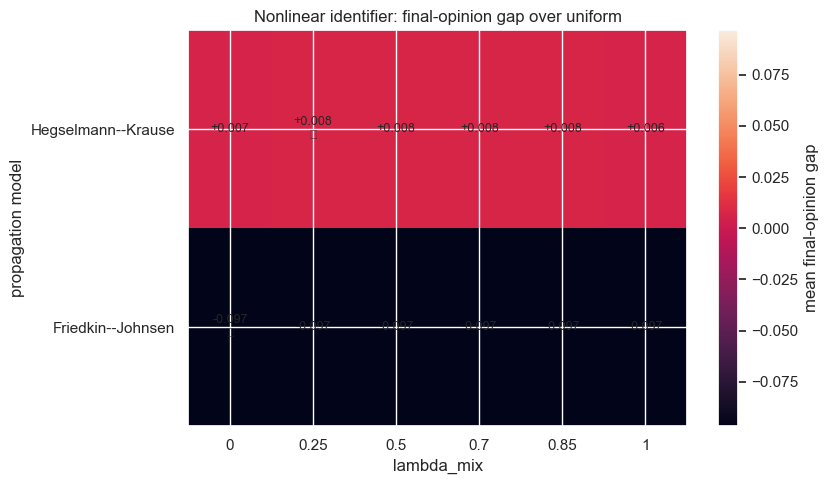

In [11]:

def annotated_heatmap(
    table: pd.DataFrame,
    *,
    title: str,
    value_label: str,
    center_zero: bool = True,
) -> None:
    values = table.to_numpy(dtype=float)

    fig, ax = plt.subplots(
        figsize=(
            max(
                8,
                0.9 * len(table.columns) + 3,
            ),
            5,
        )
    )

    if center_zero:
        maximum = float(
            np.nanmax(np.abs(values))
        )
        maximum = max(maximum, 1e-12)
        image = ax.imshow(
            values,
            aspect="auto",
            vmin=-maximum,
            vmax=maximum,
        )
    else:
        image = ax.imshow(
            values,
            aspect="auto",
        )

    ax.set_title(title)
    ax.set_xlabel("lambda_mix")
    ax.set_ylabel("propagation model")
    ax.set_xticks(
        np.arange(len(table.columns))
    )
    ax.set_xticklabels(
        [
            f"{value:g}"
            for value in table.columns
        ]
    )
    ax.set_yticks(
        np.arange(len(table.index))
    )
    ax.set_yticklabels(table.index)

    for row_index in range(table.shape[0]):
        row = values[row_index]
        finite = np.isfinite(row)
        best_column = (
            int(np.nanargmax(row))
            if finite.any()
            else None
        )

        for column_index in range(
            table.shape[1]
        ):
            value = values[
                row_index,
                column_index,
            ]

            if not np.isfinite(value):
                text = ""
            else:
                text = f"{value:+.3f}"
                if best_column == column_index:
                    text += "\n★"

            ax.text(
                column_index,
                row_index,
                text,
                ha="center",
                va="center",
                fontsize=9,
            )

    fig.colorbar(
        image,
        ax=ax,
        label=value_label,
    )
    fig.tight_layout()
    plt.show()
    plt.close(fig)


gap_table = (
    decision_summary.pivot(
        index="dynamics_label",
        columns="lambda_mix",
        values="mean",
    )
    .reindex(
        index=[
            DYNAMICS_LABELS[name]
            for name in ENABLED_DYNAMICS
        ],
        columns=LAMBDA_MIX_VALUES,
    )
)

annotated_heatmap(
    gap_table,
    title=(
        "Nonlinear identifier: final-opinion gap over uniform"
    ),
    value_label="mean final-opinion gap",
    center_zero=True,
)



## Heatmap: paired gain relative to the previous value 0.7

Every comparison uses the same propagation model, graph, initial state, and
identifier initialization. Positive values mean that the tested lambda
outperformed `0.7`.


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_35328\3245278643.py:92: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.tight_layout()


C:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


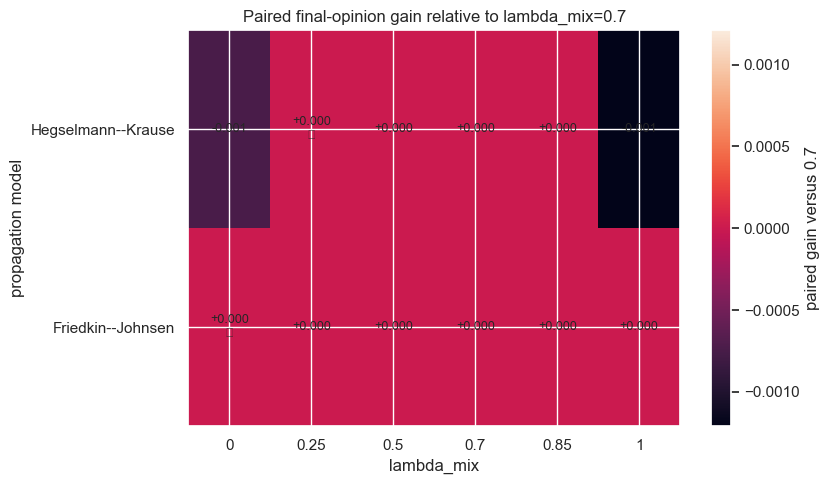

,dynamics,dynamics_label,lambda_mix,mean,std,count,sem,ci95
0,friedkinjohnsen,Friedkin--Johnsen,0.00,0.00000,0.00000,25,0.00000,0.00000
1,friedkinjohnsen,Friedkin--Johnsen,0.25,0.00000,0.00000,25,0.00000,0.00000
2,friedkinjohnsen,Friedkin--Johnsen,0.50,0.00000,0.00000,25,0.00000,0.00000
3,friedkinjohnsen,Friedkin--Johnsen,0.70,0.00000,0.00000,25,0.00000,0.00000
4,friedkinjohnsen,Friedkin--Johnsen,0.85,0.00000,0.00000,25,0.00000,0.00000
5,friedkinjohnsen,Friedkin--Johnsen,1.00,0.00000,0.00000,25,0.00000,0.00000
6,hegselmannkrause,Hegselmann--Krause,0.00,-0.00074,0.00371,25,0.00074,0.00146
7,hegselmannkrause,Hegselmann--Krause,0.25,0.00000,0.00000,25,0.00000,0.00000
8,hegselmannkrause,Hegselmann--Krause,0.50,0.00000,0.00000,25,0.00000,0.00000
9,hegselmannkrause,Hegselmann--Krause,0.70,0.00000,0.00000,25,0.00000,0.00000


In [12]:

pair_keys = [
    "dynamics",
    "dynamics_label",
    "topology_seed",
    "initial_seed",
    "trial_id",
]

reference = (
    summary_df[
        np.isclose(
            summary_df["lambda_mix"],
            REFERENCE_LAMBDA,
        )
    ][pair_keys + ["mean_end"]]
    .rename(
        columns={
            "mean_end": "mean_end_reference"
        }
    )
)

paired_reference_df = summary_df.merge(
    reference,
    on=pair_keys,
    how="inner",
)
paired_reference_df[
    "gain_vs_reference_lambda"
] = (
    paired_reference_df["mean_end"]
    - paired_reference_df[
        "mean_end_reference"
    ]
)

paired_reference_summary = mean_ci95(
    paired_reference_df,
    "gain_vs_reference_lambda",
    [
        "dynamics",
        "dynamics_label",
        "lambda_mix",
    ],
)

reference_table = (
    paired_reference_summary.pivot(
        index="dynamics_label",
        columns="lambda_mix",
        values="mean",
    )
    .reindex(
        index=[
            DYNAMICS_LABELS[name]
            for name in ENABLED_DYNAMICS
        ],
        columns=LAMBDA_MIX_VALUES,
    )
)

annotated_heatmap(
    reference_table,
    title=(
        f"Paired final-opinion gain relative to "
        f"lambda_mix={REFERENCE_LAMBDA:g}"
    ),
    value_label="paired gain versus 0.7",
    center_zero=True,
)

display(
    paired_reference_summary.sort_values(
        [
            "dynamics_label",
            "lambda_mix",
        ]
    ).round(5)
)



## Global trend and model-specific curves


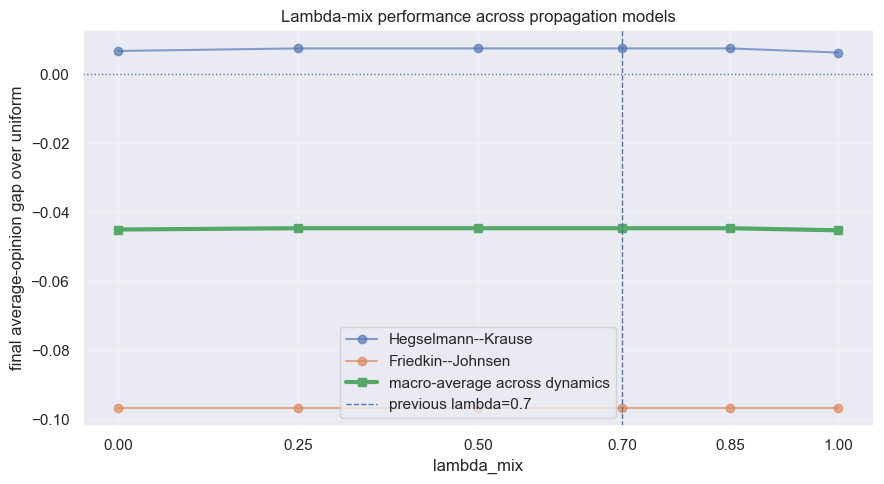

In [13]:

fig, ax = plt.subplots(figsize=(9, 5))

for dynamics in ENABLED_DYNAMICS:
    subset = decision_summary[
        decision_summary["dynamics"] == dynamics
    ].sort_values("lambda_mix")

    ax.plot(
        subset["lambda_mix"],
        subset["mean"],
        marker="o",
        alpha=0.65,
        label=DYNAMICS_LABELS[dynamics],
    )

ax.plot(
    global_summary["lambda_mix"],
    global_summary[
        "macro_mean_gap_vs_uniform"
    ],
    marker="s",
    linewidth=3,
    label="macro-average across dynamics",
)

ax.axvline(
    REFERENCE_LAMBDA,
    linestyle="--",
    linewidth=1,
    label="previous lambda=0.7",
)
ax.axhline(
    0.0,
    linestyle=":",
    linewidth=1,
)

ax.set_xlabel("lambda_mix")
ax.set_ylabel(
    "final average-opinion gap over uniform"
)
ax.set_title(
    "Lambda-mix performance across propagation models"
)
ax.set_xticks(LAMBDA_MIX_VALUES)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
plt.show()
plt.close(fig)



## Trajectories: selected common lambda versus 0.7

For every propagation model, this plot compares:

- the best macro-average common lambda
- the previous value `0.7`
- uniform allocation
- true-graph centrality

When the selected value is `0.7`, the duplicate learned curve is omitted.


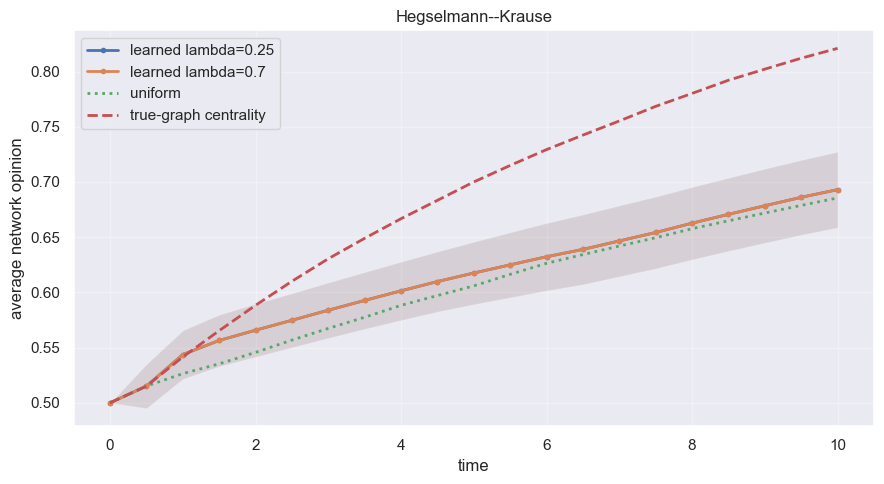

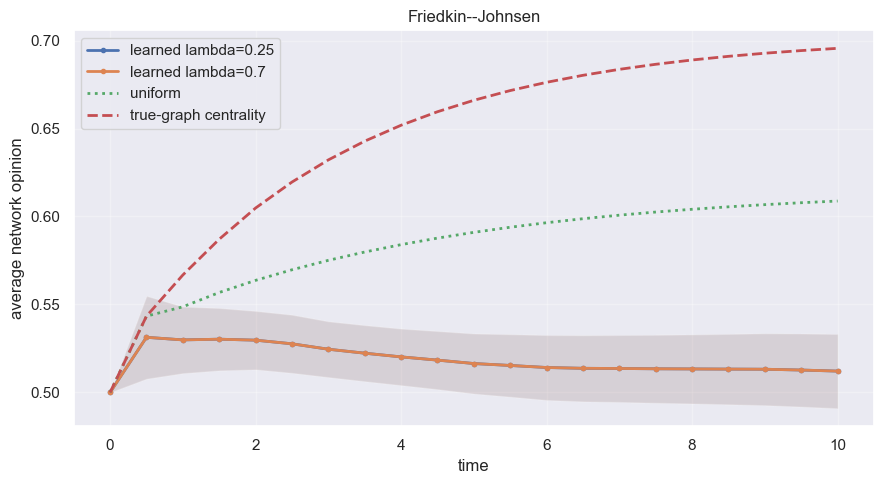

In [14]:

learned_lambdas_to_plot = list(
    dict.fromkeys(
        [
            float(best_average_lambda),
            float(REFERENCE_LAMBDA),
        ]
    )
)

for dynamics in ENABLED_DYNAMICS:
    fig, ax = plt.subplots(figsize=(9, 5))

    for lambda_mix in learned_lambdas_to_plot:
        subset = trajectory_df[
            (trajectory_df["dynamics"] == dynamics)
            & (
                trajectory_df["policy"]
                == POLICY_NONLINEAR
            )
            & np.isclose(
                trajectory_df["lambda_mix"],
                lambda_mix,
            )
        ]

        grouped = subset.groupby(
            "time"
        )["mean_opinion"]
        mean = grouped.mean()
        count = grouped.count()
        sem = (
            grouped.std(ddof=1)
            / np.sqrt(
                count.clip(lower=1)
            )
        ).fillna(0.0)

        times = mean.index.to_numpy(dtype=float)
        values = mean.to_numpy(dtype=float)
        errors = (
            1.96
            * sem.to_numpy(dtype=float)
        )

        ax.plot(
            times,
            values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=f"learned lambda={lambda_mix:g}",
        )
        ax.fill_between(
            times,
            values - errors,
            values + errors,
            alpha=0.12,
        )

    # Baselines are repeated for every lambda in the stored trajectory table.
    # Select reference lambda once to avoid duplicates.
    for policy, style in [
        (POLICY_UNIFORM, ":"),
        (POLICY_TRUE_GRAPH, "--"),
    ]:
        subset = trajectory_df[
            (trajectory_df["dynamics"] == dynamics)
            & (trajectory_df["policy"] == policy)
            & np.isclose(
                trajectory_df["lambda_mix"],
                REFERENCE_LAMBDA,
            )
        ]

        mean = (
            subset.groupby("time")[
                "mean_opinion"
            ]
            .mean()
        )

        ax.plot(
            mean.index.to_numpy(dtype=float),
            mean.to_numpy(dtype=float),
            linestyle=style,
            linewidth=2,
            label=POLICY_LABELS[policy],
        )

    ax.set_title(DYNAMICS_LABELS[dynamics])
    ax.set_xlabel("time")
    ax.set_ylabel("average network opinion")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()
    plt.close(fig)



## Fit-quality diagnostic

Because lambda changes the control trajectory, it also changes the transitions
seen by the identifier. This secondary plot checks whether differences in
control performance coincide with differences in final one-step fit quality.


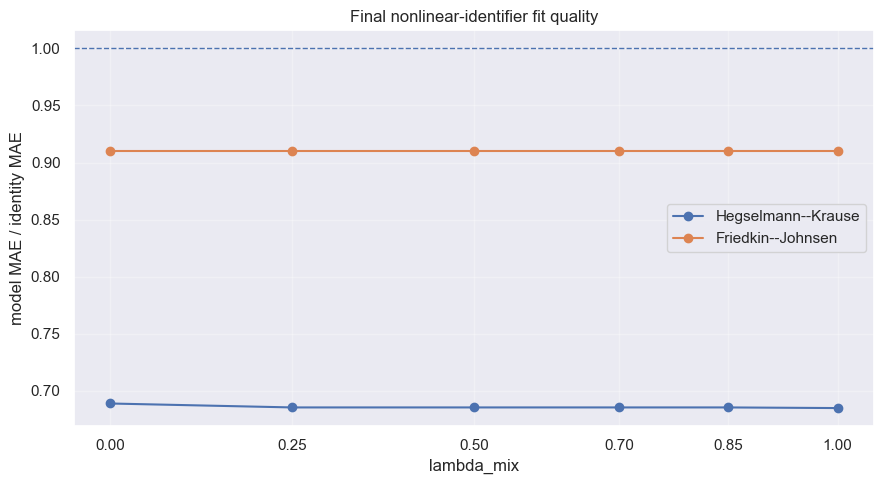

In [15]:

if (
    "final_model_over_identity"
    in summary_df.columns
):
    fit_summary = mean_ci95(
        summary_df.dropna(
            subset=[
                "final_model_over_identity"
            ]
        ),
        "final_model_over_identity",
        [
            "dynamics",
            "dynamics_label",
            "lambda_mix",
        ],
    )

    fig, ax = plt.subplots(figsize=(9, 5))

    for dynamics in ENABLED_DYNAMICS:
        subset = fit_summary[
            fit_summary["dynamics"] == dynamics
        ].sort_values("lambda_mix")

        ax.plot(
            subset["lambda_mix"],
            subset["mean"],
            marker="o",
            label=DYNAMICS_LABELS[dynamics],
        )

    ax.axhline(
        1.0,
        linestyle="--",
        linewidth=1,
    )
    ax.set_xlabel("lambda_mix")
    ax.set_ylabel(
        "model MAE / identity MAE"
    )
    ax.set_title(
        "Final nonlinear-identifier fit quality"
    )
    ax.set_xticks(LAMBDA_MIX_VALUES)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()
    plt.close(fig)



## Save analysis tables and final recommendation summary


In [16]:

decision_summary.to_csv(
    RESULTS_DIR / "lambda_mix_decision_summary.csv",
    index=False,
)
best_by_dynamics.to_csv(
    RESULTS_DIR / "lambda_mix_best_by_dynamics.csv",
    index=False,
)
global_summary.to_csv(
    RESULTS_DIR / "lambda_mix_global_summary.csv",
    index=False,
)
paired_reference_df.to_csv(
    RESULTS_DIR / "lambda_mix_paired_vs_0p7.csv",
    index=False,
)
paired_reference_summary.to_csv(
    RESULTS_DIR / "lambda_mix_paired_vs_0p7_summary.csv",
    index=False,
)

recommendation = {
    "best_macro_average_lambda": best_average_lambda,
    "best_worst_case_lambda": best_worst_case_lambda,
    "reference_lambda": REFERENCE_LAMBDA,
    "best_by_dynamics": (
        best_by_dynamics[
            [
                "dynamics",
                "dynamics_label",
                "lambda_mix",
                "mean",
                "ci95",
                "win_rate_vs_uniform",
            ]
        ]
        .to_dict(orient="records")
    ),
}

(
    RESULTS_DIR
    / "lambda_mix_recommendation.json"
).write_text(
    json.dumps(
        json_safe(recommendation),
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

print("Best macro-average lambda:", best_average_lambda)
print("Best worst-case lambda:", best_worst_case_lambda)
print("Previous lambda:", REFERENCE_LAMBDA)
print("Saved analysis outputs to:", RESULTS_DIR)


Best macro-average lambda: 0.25
Best worst-case lambda: 0.25
Previous lambda: 0.7
Saved analysis outputs to: D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_01_lambda_mix_sweep_all_dynamics_shard_1_of_3



## Interpretation rule

Prefer one common lambda for the paper unless the model-specific heatmap shows
large, stable, and scientifically interpretable differences between propagation
models.

Do not select a new value merely because its sample mean is marginally above
`0.7`. Check:

1. paired gain relative to `0.7`
2. confidence interval
3. consistency across graph/state trials
4. performance across all six propagation models
